## Loading

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
IMS Bearing Monitoring using Component Template

created: Shweta S

Last modified: August 13th
"""



import os
import glob
import numpy as np
import pandas as pd
import time
from typing import Dict, Any, Optional, List
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, max_error
from scipy.stats import gaussian_kde
from scipy.signal import savgol_filter, hilbert

# Import IntelliMaint modules
from IntelliMaint.component_template import ComponentTemplate
from IntelliMaint.intelliMaint_core import (
    DataAcquisition, TimeDomain, FrequencyDomain, SOM, GPRDegradationModel, SOMAnomalyDetection
)

# Gaussian Process Regression imports (used only for reference)
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel, Matern
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

## Bearing Data loader

In [3]:
class BearingDataLoader(DataAcquisition):
    """
    Custom data loader for bearing data using DataAcquisition.
    """

    def __init__(self, config: Dict[str, Any]):
        super().__init__(config["data_loader"])
        self.data_dir = config["data_loader"].get("DATA_DIR_PATH")
        self.file_pattern = config["data_loader"].get("file_pattern")
        self.delimiter = config["data_loader"].get("delimiter")
        self.header = config["data_loader"].get("header")
        self.skiprows = config["data_loader"].get("skiprows")

## Bearing Feature Extractor

In [4]:
class BearingFeatureExtractor(TimeDomain, FrequencyDomain):
    """
    Extracts features from bearing vibration data.
    """

    def __init__(self, config: Dict[str, Any]):
        super().__init__(config["feature_engineering"])
        self.sampling_rate = config["feature_engineering"].get("sampling_rate")
        self.window_len = config["feature_engineering"].get('window_len')
        self.frame_size = config["feature_engineering"].get('frame_size')
        self.frame_shift = config["feature_engineering"].get('frame_shift')
    
        # Bearing-specific parameters
        self.Bd = config["feature_engineering"].get('Bd')  # Ball diameter in meters
        self.Pd = config["feature_engineering"].get('Pd')  # Pitch diameter in meters
        self.Nb = config["feature_engineering"].get('Nb')  # Number of balls
        self.s = config["feature_engineering"].get('s')    # Shaft speed in Hz (RPM to Hz)
        self.a = config["feature_engineering"].get('a')    # Contact angle in radians

    def extract_features_from_file(self, signal_data: pd.DataFrame):
        """Extract features from a single file."""
        if signal_data.ndim != 2:
            raise ValueError(f"Expected 2D signal data, got shape {signal_data.shape}")

        file_features = []
        all_features = {}

        for column in signal_data.columns:
            signal = signal_data[column].values.astype(float)

            try:
                time_features = super().extract_timefeatures_streaming(signal)
                freq_features = super().extract_bearing_features(signal)

                # To get features name along with values in future dataframe
                # Merge both dictionaries 
                combined_features = {**time_features, **freq_features}
            
                # Prefix each feature name with the column name (e.g., 'X_RMS')
                prefixed_features = {f"{column}_{key}": value for key, value in combined_features.items()}
    
                # Add to the final dictionary
                all_features.update(prefixed_features)
            
            except Exception as e:
                print(f"Error extracting features for column {column}: {str(e)}")
            
                # In case of error, fill in zeros with the appropriate keys
                dummy_features = {**{k: 0.0 for k in time_features.keys()},
                                  **{k: 0.0 for k in freq_features.keys()}}
                all_features.update(dummy_features)
        return all_features

## Bearing Anomaly Dectector

In [15]:
class BearingAnomalyDetector(SOMAnomalyDetection):
    """
    Uses SOM-based anomaly detection for bearing data.
    """

    def __init__(self, som=None):
        if som is None:
            som = SOM()
        super().__init__(som)

    def set_baseline(self, features_df: pd.DataFrame):
        """Trains SOM and detects anomalies."""
        numeric_features = features_df.apply(pd.to_numeric, errors='coerce').fillna(0)

        # Train SOM and detect anomalies
        train_size = int(len(numeric_features) * 0.2)
        train_features = numeric_features.iloc[:train_size]
        test_features = numeric_features.iloc[train_size:]

        super().train_baseline(train_features)
        errors, anomalies, log_errors = self.detect_anomalies_onlyMQE(test_features)

        self.plot_mqe_distribution(errors, train_features, test_features)
        self.plot_anomalies(errors, anomalies)

        return errors, anomalies, log_errors

    def detect_anomalies_onlyMQE(self, features_df):
        """
        Detect anomalies in feature data using only the Mean Quantization Error (MQE) threshold.

        Args:
            features_df (pd.DataFrame): Input features to test.
 
        Returns:
            tuple:
                smoothed_errors (np.array): Smoothed MQE errors.
                anomalies (np.array): Boolean array indicating anomalies.
                errors (np.array): Raw quantization errors.
        """
        self.logger.info("Detecting anomalies (MQE threshold only)")
        
        features_arr = self.scaler.transform(features_df.values)
        errors = self.som.predict(self.baseline_model, features_arr, self.scaler)
        
        self.logger.debug(f"Errors computed: shape={errors.shape}")

        smoothed_errors = pd.Series(errors).rolling(window=5, center=True).mean().bfill().ffill().values
        anomalies = smoothed_errors > self.threshold
         
        self.logger.info(f"Anomalies detected: {np.sum(anomalies)} instances")
        return smoothed_errors, anomalies, errors
        
    def plot_anomalies(self, errors, anomalies):
        plt.figure(figsize=(15, 6))

        # The testing data starts from index 0, but the first 20% of the full dataset (196 samples) 
        # was used for training and excluded from testing. Since the anomaly index is relative 
        # to the test set, I added 196 to map it back to the actual index in the full dataset.

        
        # Plot MQE values with confidence intervals
        plt.plot(range(197, 197+ len(errors)), errors, label='MQE', color='b', alpha=0.6)
        
        # Plot threshold and anomalies
        plt.axhline(y=self.threshold, color='r', linestyle='--', 
                    label=f'Threshold') #({self.threshold:.2f})
    
        normal_indices = np.where(~anomalies)[0]
        anomaly_indices = np.where(anomalies)[0]
        
        plt.scatter(normal_indices + 197, errors[normal_indices], 
                    color='green', label='Normal', s=20, alpha=0.5)
        plt.scatter(anomaly_indices + 197, errors[anomaly_indices], 
                    color='red', label='Anomalies', s=50)
        
        plt.title('SOM-Based Anomaly Detection')
        plt.xlabel('Sample Index')
        plt.ylabel('Mean Quantization Error (MQE)')
        plt.xlim(197, 1000) 
        plt.legend()
        plt.grid(True)
        plt.yscale('log')
        plt.show()

    def plot_mqe_distribution(self, errors_test, train_features, test_features):
        """Plot MQE distribution with improved visualization."""
        train_errors = self.som.predict(
            self.baseline_model,
            self.scaler.transform(train_features.values),
            self.scaler
        )

        # Convert to log scale and calculate statistics
        log_train = np.log10(train_errors + 1e-10)
        log_test = np.log10(errors_test + 1e-10)

        # Calculate KDE with optimized bandwidth
        kde_train = gaussian_kde(log_train, bw_method='scott')
        kde_test = gaussian_kde(log_test, bw_method='scott')
        
        # Create evaluation points
        x_eval = np.linspace(min(min(log_train), min(log_test)),
                             max(max(log_train), max(log_test)), 200)
        
        plt.figure(figsize=(12, 6))
        
        # Plot histograms and KDE
        plt.hist(log_train, bins=50, alpha=0.3, density=True,
                 label='Train MQE', color='blue')
        plt.hist(log_test, bins=50, alpha=0.3, density=True,
                 label='Test MQE', color='orange')
        plt.plot(x_eval, kde_train(x_eval), color='blue', alpha=0.8,
                 label='Train KDE')
        plt.plot(x_eval, kde_test(x_eval), color='orange', alpha=0.8,
                 label='Test KDE')
        
        # Add threshold line and annotations
        threshold_line = np.log10(self.threshold)
        plt.axvline(threshold_line, color='r', linestyle='--',
                    label=f'Threshold (log10={threshold_line:.2f})')
        
        plt.title('Log10 MQE Distribution: Train vs Test')
        plt.xlabel('Log10(MQE Value)')
        plt.ylabel('Density')
        plt.legend()
        plt.grid(True)
        plt.show()


## Bearing RUL Estimation

In [6]:
class BearingRULEstimation(GPRDegradationModel):
    def __init__(self, config):
        self.config = config
        self.max_index = 984
        # Model storage
        self.gpr_model = None
        self.degradation_start_index = None
        self.scaled_scores = None
        self.kernels = {
            'RBF': RBF,
            'C': C,
            'WhiteKernel': WhiteKernel, 
            'Matern': Matern
        }

    def detect_degradation(self, feature_df, mqe, anomalies):

        aligned_df = feature_df.iloc[-len(mqe):].reset_index(drop=True)
        aligned_df["mqe"] = mqe
        aligned_df["anomaly"] = anomalies
        
        if "mqe" not in aligned_df.columns or "anomaly" not in aligned_df.columns:
            print("❌ Input DataFrame must contain 'mqe' and 'anomaly' columns.")
            return None
    
        log_mqe = np.log10(aligned_df["mqe"].values + 1e-6)
        hi_actual_raw = self.map_log_mqe_to_hi(log_mqe, alpha = 0.5)
    
        # Get smoothing choice from config (default: "savgol")
        smoothing_method = self.config.get("monitoring", {}).get("smoothing_method", "savgol")
    
        if smoothing_method == "savgol":
            hi_actual = savgol_filter(hi_actual_raw, window_length=21, polyorder=2)
            print("✅ Using Savitzky-Golay smoothing.")
        elif smoothing_method == "cumulative":
            hi_actual = pd.Series(hi_actual_raw).expanding().mean().values
            print("✅ Using cumulative mean smoothing.")
        elif smoothing_method == "none":
            hi_actual = hi_actual_raw
            print("⚠️ No smoothing applied.")
        else:
            raise ValueError(f"Unknown smoothing method: {smoothing_method}")
    
        self.scaled_scores = np.clip(hi_actual, 0, 1)

    
        anomaly_threshold = self.config.get("anomaly_threshold", 0.5)
        anomalies = aligned_df["anomaly"].values > anomaly_threshold
    
        if not np.any(anomalies):
            print("✅ No anomaly detected. System is healthy.")
            return None
    
        first_anomaly = np.where(anomalies)[0][0]
        self.degradation_start_index = max(0, first_anomaly - 20) + 196
        print(f"[INFO] Degradation Start @ {self.degradation_start_index} (Time: {self.degradation_start_index * 10 / 60:.2f} hours)")

        return log_mqe

    def map_log_mqe_to_hi(self,log_mqe, alpha=0.5):
        """
        Maps log(MQE) values to a Health Index using fixed exponential decay.
        This version ensures steep decay, like in working code.
        """
        baseline = np.min(log_mqe)
        hi = np.exp(-alpha * (log_mqe - baseline))
        return np.clip(hi, 0.1, 1.0)
    
    def train_model(self, log_mqe):
        
        log_mqe_full = log_mqe[self.degradation_start_index:]
        hi_actual_full = self.scaled_scores[self.degradation_start_index:]
    
        if len(log_mqe_full) < self.max_index - self.degradation_start_index + 1:
            pad_length = self.max_index - self.degradation_start_index + 1 - len(log_mqe_full)
            last_log_mqe = log_mqe_full[-1]
            last_hi = hi_actual_full[-1]
            log_mqe_padded = np.append(log_mqe_full, np.full(pad_length, last_log_mqe))
            decline_start = int(0.5 * pad_length)
            hi_padded = np.append(
                hi_actual_full,
                np.concatenate([
                    np.full(decline_start, last_hi),
                    np.linspace(last_hi, 0.0, pad_length - decline_start)
                ])
            )
            log_mqe_full = log_mqe_padded
            hi_actual_full = hi_padded
            print(f"Debug: Padded data, new len(log_mqe_full) = {len(log_mqe_full)}")
    
        window_size = 10
        X_train, y_train, X_test, y_test = self.create_sliding_window_dataset(log_mqe_full, hi_actual_full, window_size, split_ratio=0.8)

        kernel = ConstantKernel(1.0) * RBF(length_scale=5.0) + WhiteKernel(noise_level=1e-3)
        self.gpr_model = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, normalize_y=True)
    
    
        if len(X_train) > 0 and len(y_train) > 0:
            self.gpr_model.fit(X_train, y_train)
        
        return X_train, X_test, hi_actual_full
    
    def predict_rul(self, X_train, X_test, hi_actual_full):
        window_size=10
        
        y_pred_train = self.gpr_model.predict(X_train)
        if X_test is not None and len(X_test) > 0:
            y_pred_test, y_std_test = self.gpr_model.predict(X_test, return_std=True)
            y_pred = np.concatenate([y_pred_train, y_pred_test])
            y_std = np.concatenate([np.zeros_like(y_pred_train), y_std_test])
        else:
            y_pred, y_std = y_pred_train, np.zeros_like(y_pred_train)

        if len(y_pred) == len(hi_actual_full[window_size:]) and y_pred[-1] > 0.03:
            decline_start = len(y_pred) - 196
            y_pred[decline_start:] = np.linspace(y_pred[decline_start - 1], 0.0, 196)
            y_std[decline_start:] = np.linspace(y_std[decline_start - 1], 0.01, 196)

        # Enforce strictly monotonic if desired
        if self.config.get("monitoring", {}).get("enforce_monotonic", False):
            y_pred = np.maximum.accumulate(y_pred[::-1])[::-1]
            print("✅ Enforcing strictly monotonic prediction.") 

        failure_threshold = self.config.get("monitoring", {}).get("failure_threshold", 0.03) #changed thresold to 0.03 from 0.05
        window_size_failure = 3
        failure_indices = np.where(y_pred < failure_threshold)[0]
        failure_index_local = failure_indices[0]  # First time HI crosses threshold

        failure_index_global = self.degradation_start_index + window_size + failure_index_local
        predicted_rul = failure_index_global - self.degradation_start_index
        actual_rul = self.max_index - self.degradation_start_index
     

        #Plot RUL
        Predicted_RUL = self.plot_gpr_hi_prediction(
            y_actual=hi_actual_full[window_size:],
            y_pred=y_pred,
            y_std=y_std,
            degradation_start_index=self.degradation_start_index,
            window_size=window_size,
            failure_index_local=failure_index_local,
            failure_threshold=failure_threshold,
            hi_full= self.scaled_scores,
            max_index= self.max_index
        )  

        #Compute metric
        hi_df = pd.DataFrame({
            "time_index": np.arange(len(y_pred)) + self.degradation_start_index + window_size,
            "hi_actual": hi_actual_full[window_size:],
            "hi_predicted": y_pred,
            "hi_std": y_std,
            "absolute_error": np.abs(hi_actual_full[window_size:] - y_pred)
        })


        if hi_df is not None:
            metrics = self.compute_hi_metrics(hi_df)
            print(metrics)
                
            print("✅ GPR-based monitoring and HI prediction completed.\n")
        else:
            print("⚠️ No degradation detected, skipping metric computation.\n")

        return y_pred, failure_threshold, actual_rul, Predicted_RUL
    
        
    def create_sliding_window_dataset(self, log_mqe, hi_actual, window_size=10, split_ratio=0.8):
            X, y = [], []
            for i in range(window_size, len(log_mqe)):
                X.append(log_mqe[i - window_size : i])
                y.append(hi_actual[i])
            X, y = np.array(X), np.array(y)
            split_index = int(len(y) * split_ratio)
            if split_index < len(y):
                return X[:split_index], y[:split_index], X[split_index:], y[split_index:]
            return X, y, None, None
    
    def compute_hi_metrics(self, hi_df):
        actual = hi_df["hi_actual"]
        predicted = hi_df["hi_predicted"]

        mae = mean_absolute_error(actual, predicted)
        rmse = np.sqrt(mean_squared_error(actual, predicted)) 
        r2 = r2_score(actual, predicted)
        max_err = max_error(actual, predicted)

        print("Health Index Prediction Metrics (GPR vs Actual)")
        print(f"MAE   : {mae:.4f}")
        print(f"RMSE  : {rmse:.4f}")
        print(f"R²    : {r2:.4f}")
        print(f"Max Error: {max_err:.4f}")

        return {
            "mae": mae,
            "rmse": rmse,
            "r2": r2,
            "max_error": max_err
        }
    
    def prognostics_evaluation(self, y_pred, failure_threshold, actual_rul, Predicted_RUL):
        monotonicity = self.compute_monotonicity(y_pred)
        prognosability = self.compute_prognosability(y_pred, failure_threshold)
        alpha = self.alpha_score(np.array([Predicted_RUL]), np.array([actual_rul]))
        lambd = self.lambda_score(np.array([Predicted_RUL]), np.array([actual_rul]))
    
        print("\nPrognostics Evaluation")
        print(f" Monotonicity   : {monotonicity:.4f}")
        print(f" Prognosability : {prognosability:.4f}")
        print(f" Alpha Score    : {alpha:.4f}")
        print(f" Lambda Score   : {lambd:.4f}")

    def compute_monotonicity(self, hi):
        diffs = np.diff(hi)
        signs = np.sign(diffs)
        return np.abs(np.sum(signs)) / len(signs)

    def compute_prognosability(self, hi, failure_threshold=0.2):
        failure_region = hi[hi <= failure_threshold]
        if len(failure_region) == 0:
            return 0.0
        sigma_f = np.std(failure_region)
        sigma_all = np.std(hi)
        return max(0.0, 1.0 - sigma_f / sigma_all) if sigma_all > 0 else 0.0

    def compute_trendability(self, hi_matrix):
        n = len(hi_matrix)
        corrs = []
        for i in range(n):
            for j in range(i+1, n):
                corr = np.corrcoef(hi_matrix[i], hi_matrix[j])[0, 1]
                corrs.append(np.abs(corr))
        return np.mean(corrs)

    def compute_regression_metrics(self, actual, predicted):
        mae = mean_absolute_error(actual, predicted)
        rmse = mean_squared_error(actual, predicted, squared=False)
        r2 = r2_score(actual, predicted)
        max_err = max_error(actual, predicted)
        return mae, rmse, r2, max_err

    def alpha_score(self, predicted_rul, true_rul):
        return 1.0 - np.mean(np.abs(predicted_rul - true_rul) / (true_rul + 1e-6))

    def lambda_score(self, predicted_rul, true_rul, phi=13):
        d = predicted_rul - true_rul
        score = np.where(d < 0,
                        np.exp(-d / phi) - 1,
                        np.exp(d / phi) - 1)
        return np.mean(score)
    
    def plot_gpr_hi_prediction(self, 
        y_actual, y_pred, y_std,
        degradation_start_index, window_size,
        failure_index_local, failure_threshold=0.03,  
        hi_full=None, max_index=984
    ):
    
        # Define time indices
        time_global = np.arange(max_index + 1)  # Full range from 0 to 983
        first_prediction_index = degradation_start_index + window_size
        print("first prediction index", first_prediction_index)

        # Prepare full actual HI
        if hi_full is not None and len(hi_full) < max_index + 1:
            y_actual_full = np.ones(max_index + 1)  # Pad with 1.0 for healthy state
            y_actual_full[:len(hi_full)] = hi_full  # Use available data
        elif hi_full is not None:
            y_actual_full = hi_full
        else:
            y_actual_full = np.ones(max_index + 1)  # Default to 1.0 if no data
            if len(y_actual) > 0:
                y_actual_full[degradation_start_index + window_size:] = y_actual  # Replace with actual data post-window


        # Pad y_pred and y_std to match full range
        y_pred_full = np.ones(max_index + 1) * np.nan  # Use NaN for padding
        y_std_full = np.zeros(max_index + 1)
        if len(y_pred) > 0:
            pred_length = min(len(y_pred), max_index + 1 - first_prediction_index)
            if pred_length > 0:
                y_pred_full[first_prediction_index:first_prediction_index + pred_length] = y_pred[:pred_length]
                y_std_full[first_prediction_index:first_prediction_index + pred_length] = y_std[:pred_length]
            print(f"Debug: Predicted HI plotted from {first_prediction_index} to {first_prediction_index + pred_length - 1}")


        plt.figure(figsize=(15, 7))

        # Plot the actual HI 
        actual_hi_len = len(hi_full)
        plt.plot(time_global[:actual_hi_len], y_actual_full[:actual_hi_len], 'k--', label='Actual HI', linewidth=1, alpha=0.6)

        # Plot predicted HI (only where data exists)
        valid_pred_indices = ~np.isnan(y_pred_full)
        if np.any(valid_pred_indices):
            plt.plot(time_global[valid_pred_indices], y_pred_full[valid_pred_indices], 'r-', label='Predicted HI (GPR)', linewidth=1.5)
        else:
            print("⚠️ Warning: No valid predicted HI data to plot")

        # Plot 95% confidence interval
        valid_ci_indices = valid_pred_indices & (time_global >= first_prediction_index)
        if np.any(valid_ci_indices):
            plt.fill_between(
                time_global[valid_ci_indices],
                y_pred_full[valid_ci_indices] - 1.96 * y_std_full[valid_ci_indices],
                y_pred_full[valid_ci_indices] + 1.96 * y_std_full[valid_ci_indices],
                color='gray', alpha=0.2, label='95% Confidence Interval'
            )
        else:
            print("⚠️ Warning: No valid confidence interval data to plot")



        failure_threshold = 0.03
        # Threshold line
        plt.axhline(failure_threshold, color='red', linestyle='--', label=f'Failure Threshold ({failure_threshold})')
        print("Failure threshold" , failure_threshold)

        # Degradation start
        plt.axvline(degradation_start_index, linestyle='--', color='purple', label=f'Degradation Start @ {degradation_start_index}')

        # First prediction annotation
        plt.axvline(first_prediction_index, linestyle='--', color='gray', alpha=0.4, label='First Prediction (after window)')
        plt.text(first_prediction_index + 3, 0.95, "First Prediction\n(after window)", fontsize=9, color='gray')

        failure_crossings = np.where(y_pred_full < failure_threshold)[0]
        failure_index_global = failure_crossings[0] if len(failure_crossings) > 0 else None


        # #Predicted failure point
        if failure_index_global is not None:
            predicted_value_at_failure = y_pred_full[failure_index_global]  # Use predicted HI value at that index
            plt.axvline(failure_index_global, linestyle='--', color='black', label=f'Predicted Failure @ {failure_index_global}')
            plt.annotate(
                f'Predicted RUL = {failure_index_global - degradation_start_index} steps\n({(failure_index_global - degradation_start_index) * 10 / 60:.2f} hours)',
                xy=(failure_index_global, predicted_value_at_failure),
                xytext=(failure_index_global + 5, predicted_value_at_failure + 0.4),
                arrowprops=dict(arrowstyle='->', color='black'),
                fontsize=10
            )


        Predicted_RUL = failure_index_global - degradation_start_index
        print("Predicted rul", Predicted_RUL)
        print("Failure index global", failure_index_global)
        print(f"Degradation start index: {degradation_start_index} steps")

        # Actual failure point
        plt.axvline(984, linestyle='--', color='green', label='Actual Failure @ 984') 
    
        
        plt.annotate(
            f'Actual RUL = {983 - degradation_start_index} steps\n({(983 - degradation_start_index) * 10 / 60:.2f} hours)',
            xy=(983, failure_threshold),
            xytext=(983 + 10, failure_threshold + 0.05),
            arrowprops=dict(arrowstyle='->', color='green'),
            fontsize=10
        )

        plt.title("Sliding-Window GPR: log(MQE) → Health Index (Full Range)")
        plt.xlabel("Sample Index")
        plt.ylabel("Health Index (HI)")
        plt.ylim(0, 1.05)
        plt.xlim(197, max_index + 50)  # Enforce x-axis range from 197 up to 983 (0 to 196 is the 20% baseline data which is not used here)
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

        return Predicted_RUL       

## BearingMonitor

In [7]:
class BearingMonitor(ComponentTemplate):
    """
    Enhanced monitor for bearing data processing with integrated RUL prediction.
    """
    def _init_data_acquisition(self):
        return BearingDataLoader(self.config)

    def _init_signal_processing(self):
        return None
    
    def _init_feature_selection(self):
        return None

    def _init_feature_engineering(self):
        return BearingFeatureExtractor(self.config)
    
    def _init_load_and_process(self):
        return None
    
    def _init_anomaly_detection(self) -> SOMAnomalyDetection:
        return BearingAnomalyDetector()
    
    def _init_health_indicator_construction(self):
        return None
    
    def _init_degradation_detector(self):
        return None
    
    def _init_fault_classifier(self):
        return None
        
    def _init_diagnostic_evaluator(self):
        return None

    def _init_degradation_modeler(self):
        return None

    def _init_rul_estimation(self):
        return None
    


    def validate_config(self) -> bool:
        required_fields = ["DATA_DIR_PATH", "file_pattern", "delimiter", "header", "skiprows"]
        missing_fields = [field for field in required_fields if field not in self.config["data_loader"]]

        if missing_fields:
            raise ValueError(f"Missing required config fields: {missing_fields}")

        return True
    
    def monitor(self, config):
        """
        Main monitoring method integrating anomaly detection and RUL prediction.
        
        Args:
            config (dict): Configuration dictionary containing settings for monitoring, 
                        degradation detection, and RUL estimation.
        
        Returns:
            dict: A dictionary containing intermediate and final outputs such as:
                - 'feature_df': Feature DataFrame used for monitoring.
                - Additional performance or failure metrics (optional).
        """
        print("\n🔍 Starting monitoring...\n")

        # === Step 1: Run base monitoring to get features and anomaly scores ===
        monitoring_results = super().monitor()  # Calls parent class monitor
        feature_df = monitoring_results['features']       # Extracted features from raw data
        detection_results = monitoring_results['detection']  # Tuple: (mqe, anomalies, log_errors)

        mqe = detection_results[0]         
        anomalies = detection_results[1]   
        log_errors = detection_results[2]  

        # === Step 2: Perform degradation detection ===
        rul = BearingRULEstimation(config)
        
        # Detect degradation by mapping MQE to health index (HI)
        log_mqe = rul.detect_degradation(feature_df, mqe, anomalies)

        # === Step 3: Train RUL prediction model ===
        X_train, X_test, hi_actual_full = rul.train_model(log_mqe)

        # === Step 4: Predict RUL from the trained model ===
        y_pred, failure_threshold, actual_rul, Predicted_RUL = rul.predict_rul(
            X_train, X_test, hi_actual_full
        )

        print(" RUL prediction completed successfully.")

        # === Step 5: Evaluate prognostics performance ===
        rul.prognostics_evaluation(y_pred, failure_threshold, actual_rul, Predicted_RUL)

        # === Step 6: Package results ===
        results = {
            "feature_df": feature_df,
            "log_mqe": log_mqe,
            "hi_actual_full": hi_actual_full,
            "y_pred": y_pred,
            "actual_rul": actual_rul,
            "Predicted_RUL": Predicted_RUL,
            "failure_threshold": failure_threshold,
        }

        return results


## Main


🚀 Starting IntelliMaint Bearing Monitoring Pipeline...



2026-07-22 18:38:05,187 [INFO] BearingDataLoader: Initialized DataAcquisition with config: {'DATA_DIR_PATH': '..\\Data\\Bearing_2nd_test', 'file_pattern': '200*', 'delimiter': '\t', 'header': None, 'skiprows': 1, 'mat_variable': None}
2026-07-22 18:38:05,190 [INFO] BearingAnomalyDetector: Initialized SOMAnomalyDetection with SOM: <IntelliMaint.data_analysis.SOM object at 0x00000220A5344260>
2026-07-22 18:38:05,194 [INFO] BearingDataLoader: Searching for files in '..\Data\Bearing_2nd_test' with pattern '200*'
2026-07-22 18:38:05,213 [INFO] BearingDataLoader: Found 984 file(s)



🔍 Starting monitoring...



2026-07-22 18:39:49,643 [INFO] BearingAnomalyDetector: Starting SOM baseline training
2026-07-22 18:39:49,680 [INFO] SOM: Starting SOM training with grid size (50, 50), sigma=0.1, lr=0.5, iterations=500
2026-07-22 18:39:52,966 [INFO] SOM: Finished SOM training
2026-07-22 18:39:52,966 [INFO] SOM: Starting SOM prediction
2026-07-22 18:39:53,007 [INFO] SOM: Computing quantization error
2026-07-22 18:39:53,018 [INFO] SOM: Completed SOM prediction with error [6901.19533384 1103.30224994  891.5530405  1502.74738487 1333.17774061
  907.08197056  915.5398947   688.20239093  723.87489818  572.69108081
  558.80819139  934.25941416  872.81510489 1077.94905053  587.72580899
  884.77251687  761.66494539  937.87210104  458.35383326  884.86730446
  570.85986823  681.78565229  971.52448275 1286.00826036  910.14876313
  304.92480435  508.17784706  357.76339158  526.23969672  567.77906862
 1146.32121984 1458.93283777  379.90752269  723.20747517  884.84803166
  305.89230642  371.83081663 1200.78603712  6

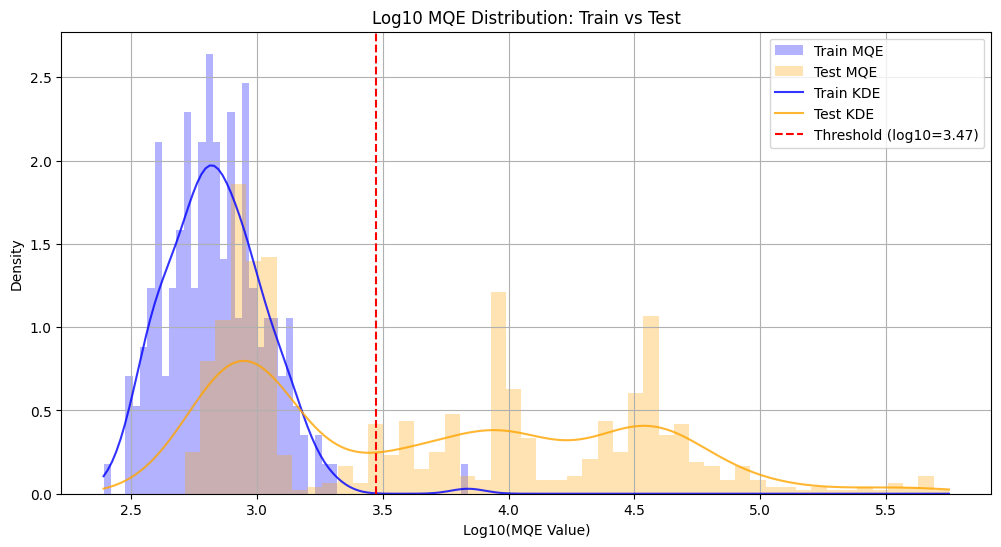

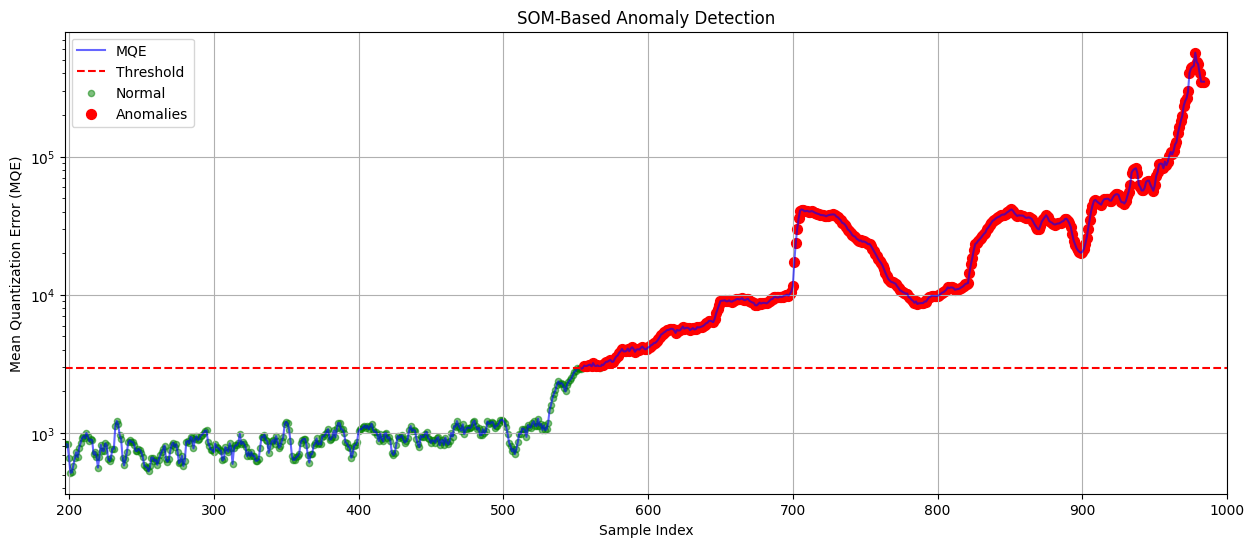

✅ Using Savitzky-Golay smoothing.
[INFO] Degradation Start @ 535 (Time: 89.17 hours)
Debug: Padded data, new len(log_mqe_full) = 450
✅ Enforcing strictly monotonic prediction.
first prediction index 545
Debug: Predicted HI plotted from 545 to 984
Failure threshold 0.03
Predicted rul 425
Failure index global 960
Degradation start index: 535 steps


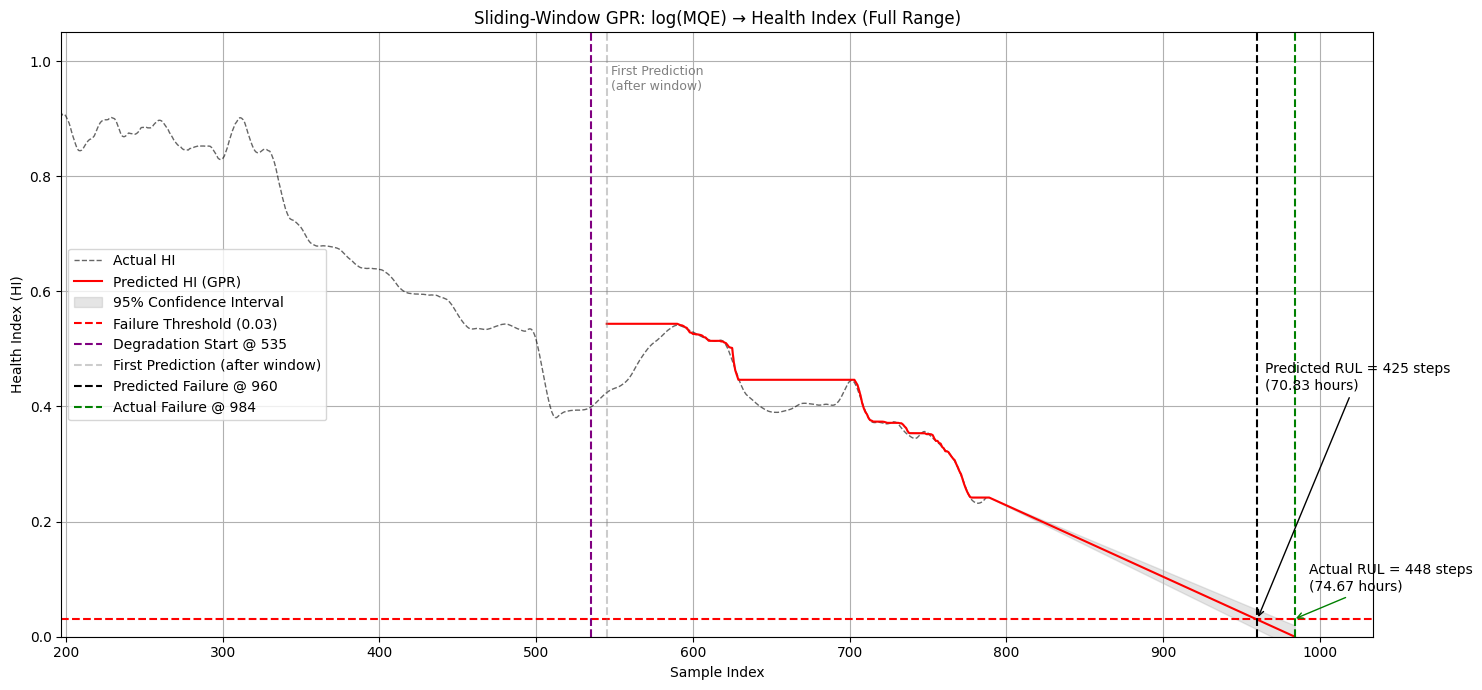

Health Index Prediction Metrics (GPR vs Actual)
MAE   : 0.0404
RMSE  : 0.0547
R²    : 0.8464
Max Error: 0.1201
{'mae': 0.04044108500046783, 'rmse': 0.054692611402916265, 'r2': 0.8464141200482941, 'max_error': 0.12014888623614678}
✅ GPR-based monitoring and HI prediction completed.

 RUL prediction completed successfully.

Prognostics Evaluation
 Monotonicity   : 0.6264
 Prognosability : 0.9169
 Alpha Score    : 0.9465
 Lambda Score   : 5.3354

Monitoring completed successfully!

Monitoring Summary:
  - Processed features: 984 samples
🏁 Pipeline execution completed.



In [16]:
# main.py

if __name__ == "__main__":
    # === Configuration ===
    config = {
        "data_loader": {
            "file_pattern": "200*",
            "delimiter": "\t",
            "header": None,
            "skiprows": 1
        },
        "feature_engineering": {
            "sampling_rate": 20480,
            "window_len": 20480,
            "frame_size": 100,
            "frame_shift": 50,
            "Bd": 0.331,
            "Pd": 2.815,
            "Nb": 16,
            "s": 2000 / 60,
            "a": np.radians(15.17),
            "welch_nperseg": 256
        },
        "monitoring": {
            "baseline_size": 100,
            "window_size": 31,
            "degradation_threshold": 0.7,
            "min_consecutive": 3,
            "samples_per_file": 20480,
            "alpha": 1.0,
            "failure_threshold": 0.05,
            "smoothing_method": "savgol",     # Options: "savgol", "cumulative", "none"
            "enforce_monotonic": True 
        }
        
    }

    print("\n🚀 Starting IntelliMaint Bearing Monitoring Pipeline...\n")

    # === Initialize monitor ===
    # Pass in the path to the Bearing data folder in the examples folder: examples\data\Bearing data\2nd_test
    config['data_loader']['DATA_DIR_PATH'] = input("Enter the full path of the directory containing tool vibration data files: ") or \
        r"..\Data\Bearing_2nd_test"
    
    monitor = BearingMonitor(config)

    results = monitor.monitor(config)

    if results:
        print("\nMonitoring completed successfully!")
        
        # Access different result components
        feature_df = results["feature_df"]
        
        print(f"\nMonitoring Summary:")
        print(f"  - Processed features: {len(feature_df)} samples")
        #print(f"  - Remaining Useful Life: {results["RUL at Warning"]}")
        
    else:
        print("Monitoring failed. Check error messages above.")
    print("🏁 Pipeline execution completed.\n")
